In [ ]:
import sys  # noqa: I001

sys.path.append("..")


import importlib
import subprocess
import typing

from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score
from src.eval_utils.mmlu_utils import category_from_subject, subcategory_from_subject


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)


matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["text.latex.preamble"] = "\\usepackage{libertinus}"

sns.set_style("white")
sns.set_context("notebook", font_scale=1.1)

In [2]:
dataset = load_dataset("../data/mmlu_predictions", data_files="test.parquet", split="train")
df = dataset.to_pandas()
df = typing.cast(pd.DataFrame, df)

MODELS_RENAME = {
    "../MIIA-14B": "MIIA-14B",
    "Fastweb/FastwebMIIA-7B": "MIIA-7B",
    "Qwen/Qwen3.5-9B": "Qwen3.5",
    "Qwen/Qwen3-8B": "Qwen3",
    "sapienzanlp/Minerva-7B-instruct-v1.0": "Minerva",
    "swap-uniba/LLaMAntino-3-ANITA-8B-Inst-DPO-ITA": "LLaMAntino-3",
    "utter-project/EuroLLM-9B-Instruct-2512": "EuroLLM",
    "swiss-ai/Apertus-8B-Instruct-2509": "Apertus",
}
LANGS_ORDER = ["English", "Italian", "Friulian", "Sicilian", "Ligurian", "Lombard", "Venetian"]
MODELS_ORDER = ["Minerva", "MIIA-7B", "MIIA-14B", "LLaMAntino-3", "EuroLLM", "Qwen3", "Qwen3.5", "Apertus"]

MODELS_COLORS = {
    "Minerva": "#D61B4E",
    "MIIA-7B": "#FF4D00",
    "MIIA-14B": "#FFA600",
    "LLaMAntino-3": "#009CE6",
    "EuroLLM": "#1A6FB8",
    "Qwen3": "#9FE6A8",
    "Qwen3.5": "#9B86F0",
    "Apertus": "#FF8036",
}

df["model"] = df["model"].map(MODELS_RENAME)
df["model"] = df["model"].astype(pd.CategoricalDtype(MODELS_ORDER))
df["lang"] = df["lang"].astype(pd.CategoricalDtype(LANGS_ORDER))

df["category"] = df["subset"].map(category_from_subject)
df["subcategory"] = df["subset"].map(subcategory_from_subject)

In [3]:
df = typing.cast(pd.DataFrame, df)
models = df["model"].unique()

for _, model in enumerate(models):
    model_df = df[df["model"] == model]
    pred = model_df["prediction"].astype(str)
    print(f"Model: {model}")
    counts = pred.value_counts()[:20]  # Show top 20 predictions
    print(", ".join(f"{label} ({count})" for label, count in counts.items()))
    print()

Model: MIIA-14B
C (14786), A (9300), B (7687), D (5412), S (96), 5 (8), i (7), I (4), II (2), 17 (1), Venerdì (1), F (1), 135 (1), 32 (1), uno (1), sette (1), Sì (1)

Model: MIIA-7B
A (11325), C (11050), B (8436), D (6309), S (93), Ve (5), I (4), T (4), 300 (4), i (4), II (3), 5 (3), pen (3), W (3), H (2), Respons (2), 95 (2), 0 (2), 8 (2), Gi (2)

Model: Qwen3
D (10424), C (9357), B (9149), A (8380)

Model: Qwen3.5
C (10630), B (9509), D (8794), A (8377)

Model: Minerva
A (27175), C (6489), D (1577), B (1462), II (140), I (103), III (90), ii (61), X (20), 1 (16), 2 (14), i (9), 7 (7), E (7), iii (7), 3 (6), M (5), Artic (5), x (5), V (4)

Model: LLaMAntino-3
D (11817), B (9696), C (8304), A (5956), 3 (142), 1 (117), 2 (111), 4 (71), 0 (68), 8 (65), 5 (62), 7 (48), 6 (47), 9 (44), 12 (30), 20 (26), 10 (21), 25 (20), 100 (16), 15 (15)

Model: Apertus
C (10709), B (10546), D (8785), A (7244), M (7), I (5), ii (4), II (2), c (2), L (2), n (1), T (1), b (1), m (1)

Model: EuroLLM
A (11636)

In [4]:
# row = df[df["prediction"].str.contains("III")].iloc[1]
# print(row["question"])
# print(row["choices"])
# print(row["answer"])

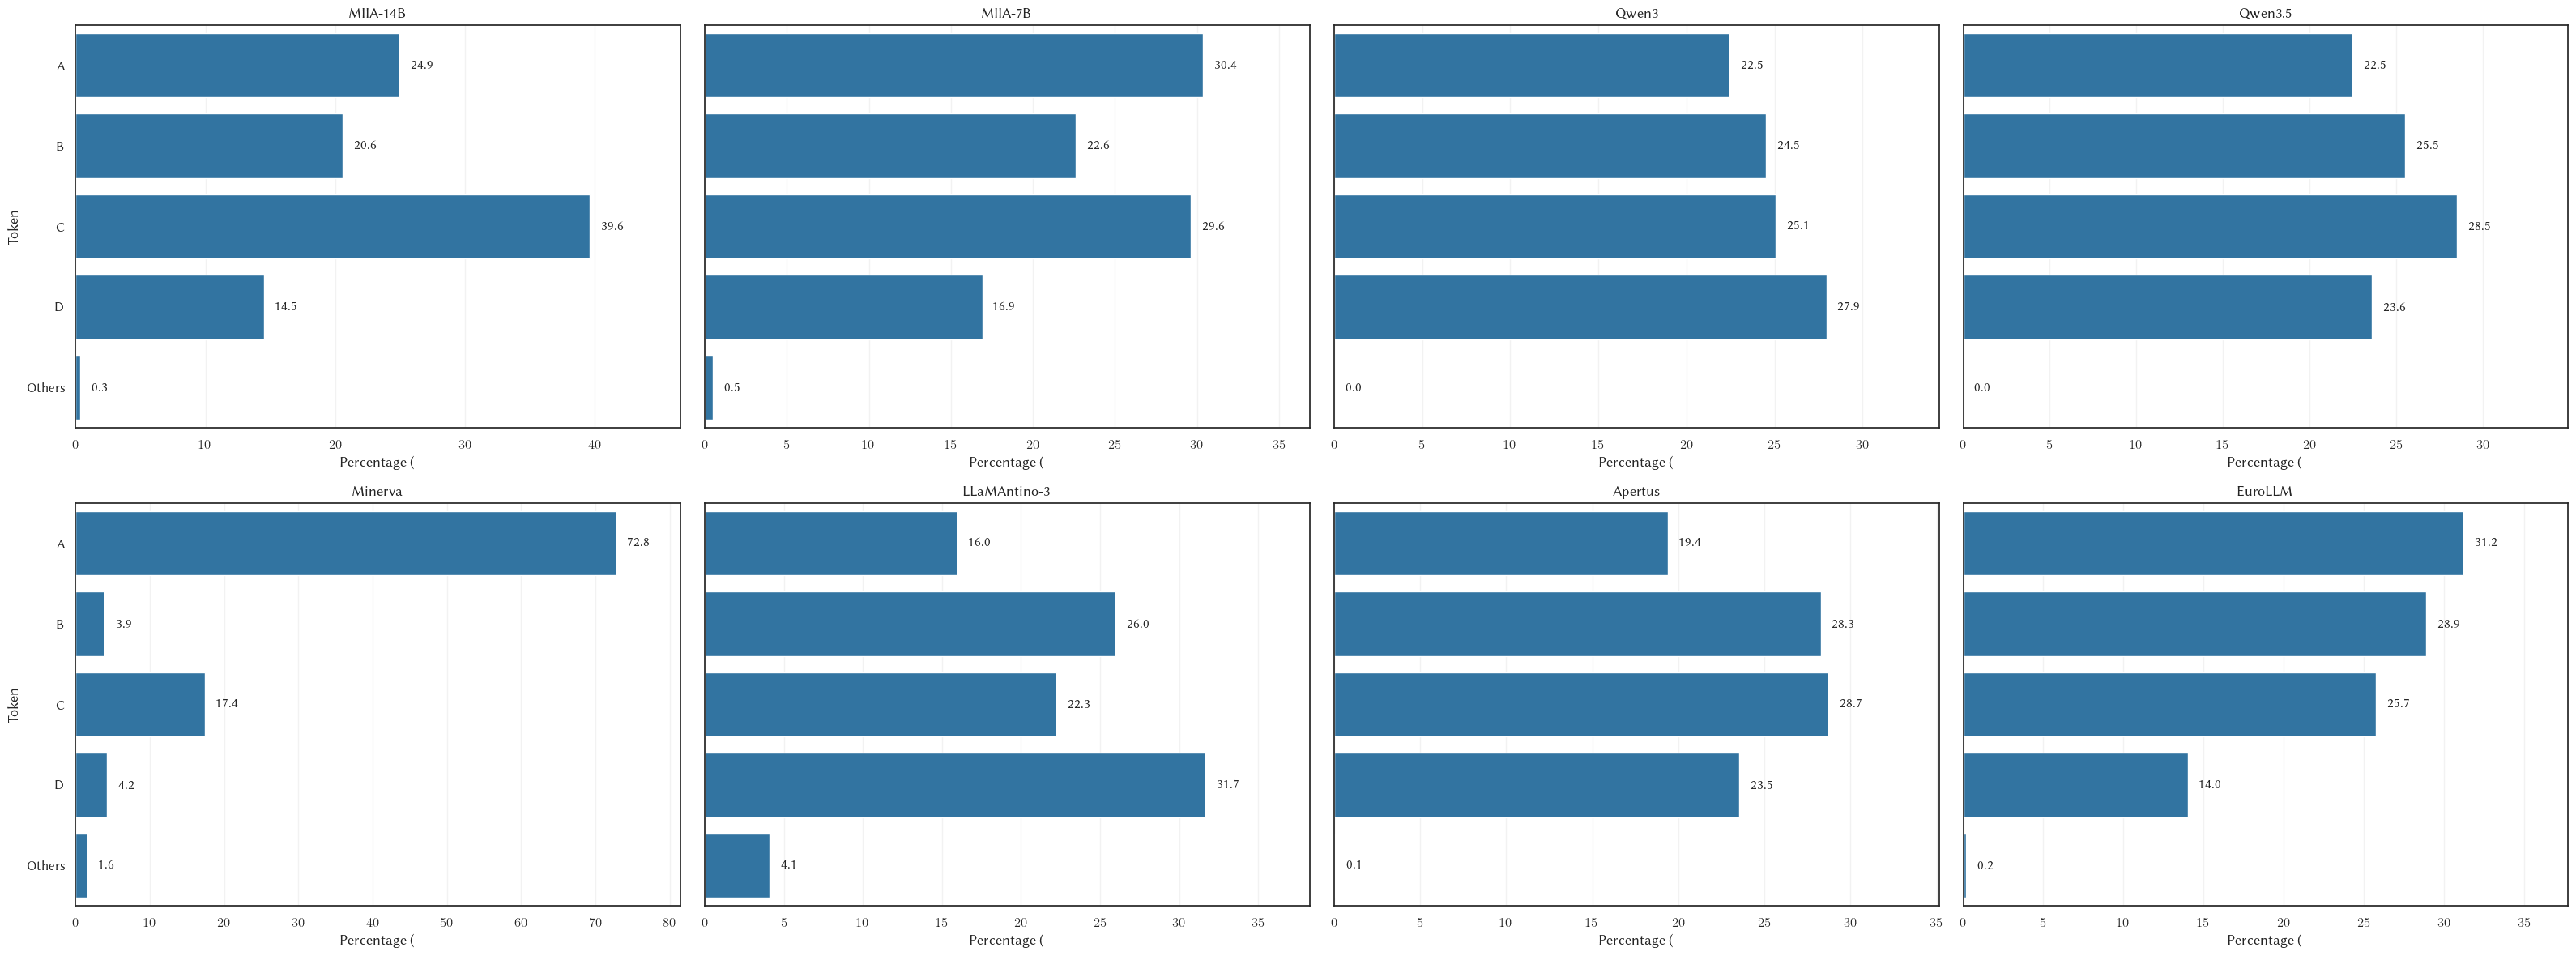

In [5]:
# token percentage per model with non A/B/C/D aggregated as Others
ncols = len(models) // 2 + len(models) % 2
fig, axes = plt.subplots(nrows=2, ncols=ncols, figsize=(8 * ncols, 12), sharey=True)
axes = np.atleast_1d(axes).flatten()

valid_tokens = {"A", "B", "C", "D"}
token_order = ["A", "B", "C", "D", "Others"]

for i, model in enumerate(models):
    model_df = df[df["model"] == model]
    pred = model_df["prediction"].astype(str).str.strip().str.upper()

    grouped = pred.where(pred.isin(valid_tokens), "Others")
    token_pct = grouped.value_counts(normalize=True).reindex(token_order, fill_value=0).mul(100)

    sns.barplot(x=token_pct.values, y=token_pct.index, ax=axes[i])
    axes[i].set_title(f"{model}")
    axes[i].set_xlabel("Percentage (%)")
    axes[i].set_ylabel("Token")
    axes[i].set_xlim(0, axes[i].get_xlim()[1] + 5)  # Ensure x-axis starts at 0
    axes[i].grid(axis="x", alpha=0.25)

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt="%.1f%%", padding=10, fontsize=12)

# hide any unused subplots
for j in range(len(models), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
# print percentage of others tokens per model and language
others_count = df[~df["prediction"].isin(valid_tokens)].groupby(["model", "lang"], observed=False).size()
total_count = df.groupby(["model", "lang"], observed=False).size()
df_total = total_count.unstack(level=0).T.fillna(0).astype(int)

df_percentage = others_count.unstack(level=0).T.fillna(0).astype(int)
df_percentage["Total"] = df_percentage.sum(axis=1)
df_percentage = df_percentage.sort_values("Total", ascending=False)
df_percentage["Percentage"] = df_percentage["Total"] / df_total.sum(axis=1) * 100
df_percentage["Percentage"] = df_percentage["Percentage"].round(2).astype(str) + "%"
df_percentage

lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian,Total,Percentage
model,,,,,,,,,
LLaMAntino-3,491,364,89,250,105,59,179,1537,4.12%
Minerva,37,76,74,40,100,195,85,607,1.63%
MIIA-7B,11,6,75,3,56,5,34,190,0.51%
MIIA-14B,2,2,2,1,110,3,5,125,0.34%
EuroLLM,3,2,6,0,42,4,1,58,0.16%
Apertus,1,1,3,3,9,3,6,26,0.07%
Qwen3,0,0,0,0,0,0,0,0,0.0%
Qwen3.5,0,0,0,0,0,0,0,0,0.0%


In [7]:
USE_LOGPROBS = False


def map_prediction(label: str) -> int:
    label_to_id = {"A": 0, "B": 1, "C": 2, "D": 3}
    return label_to_id.get(label, -1)


if USE_LOGPROBS:
    # using logprobs
    df["prediction"] = df["probs"].map(lambda x: np.argmax(x))
else:
    # using predicted token (exact match)
    df["prediction"] = df["prediction"].map(lambda x: map_prediction(x.strip()))

df["confidence"] = df["probs"].map(np.max)
df["correct"] = (df["prediction"] == df["answer"]).astype(int)

In [8]:
# compute F1 metrics per language and model
df = typing.cast(pd.DataFrame, df)


def compute_metrics(group: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "f1_macro": f1_score(group["answer"], group["prediction"], average="macro", zero_division=0),
            "f1_weighted": f1_score(group["answer"], group["prediction"], average="weighted", zero_division=0),
            "accuracy": accuracy_score(group["answer"], group["prediction"]),
            "avg_confidence": group["confidence"].mean(),
        }
    )


metrics_df = df.groupby(["lang", "model"], as_index=False, observed=True).apply(compute_metrics, include_groups=False)  # pyright: ignore[reportCallIssue]

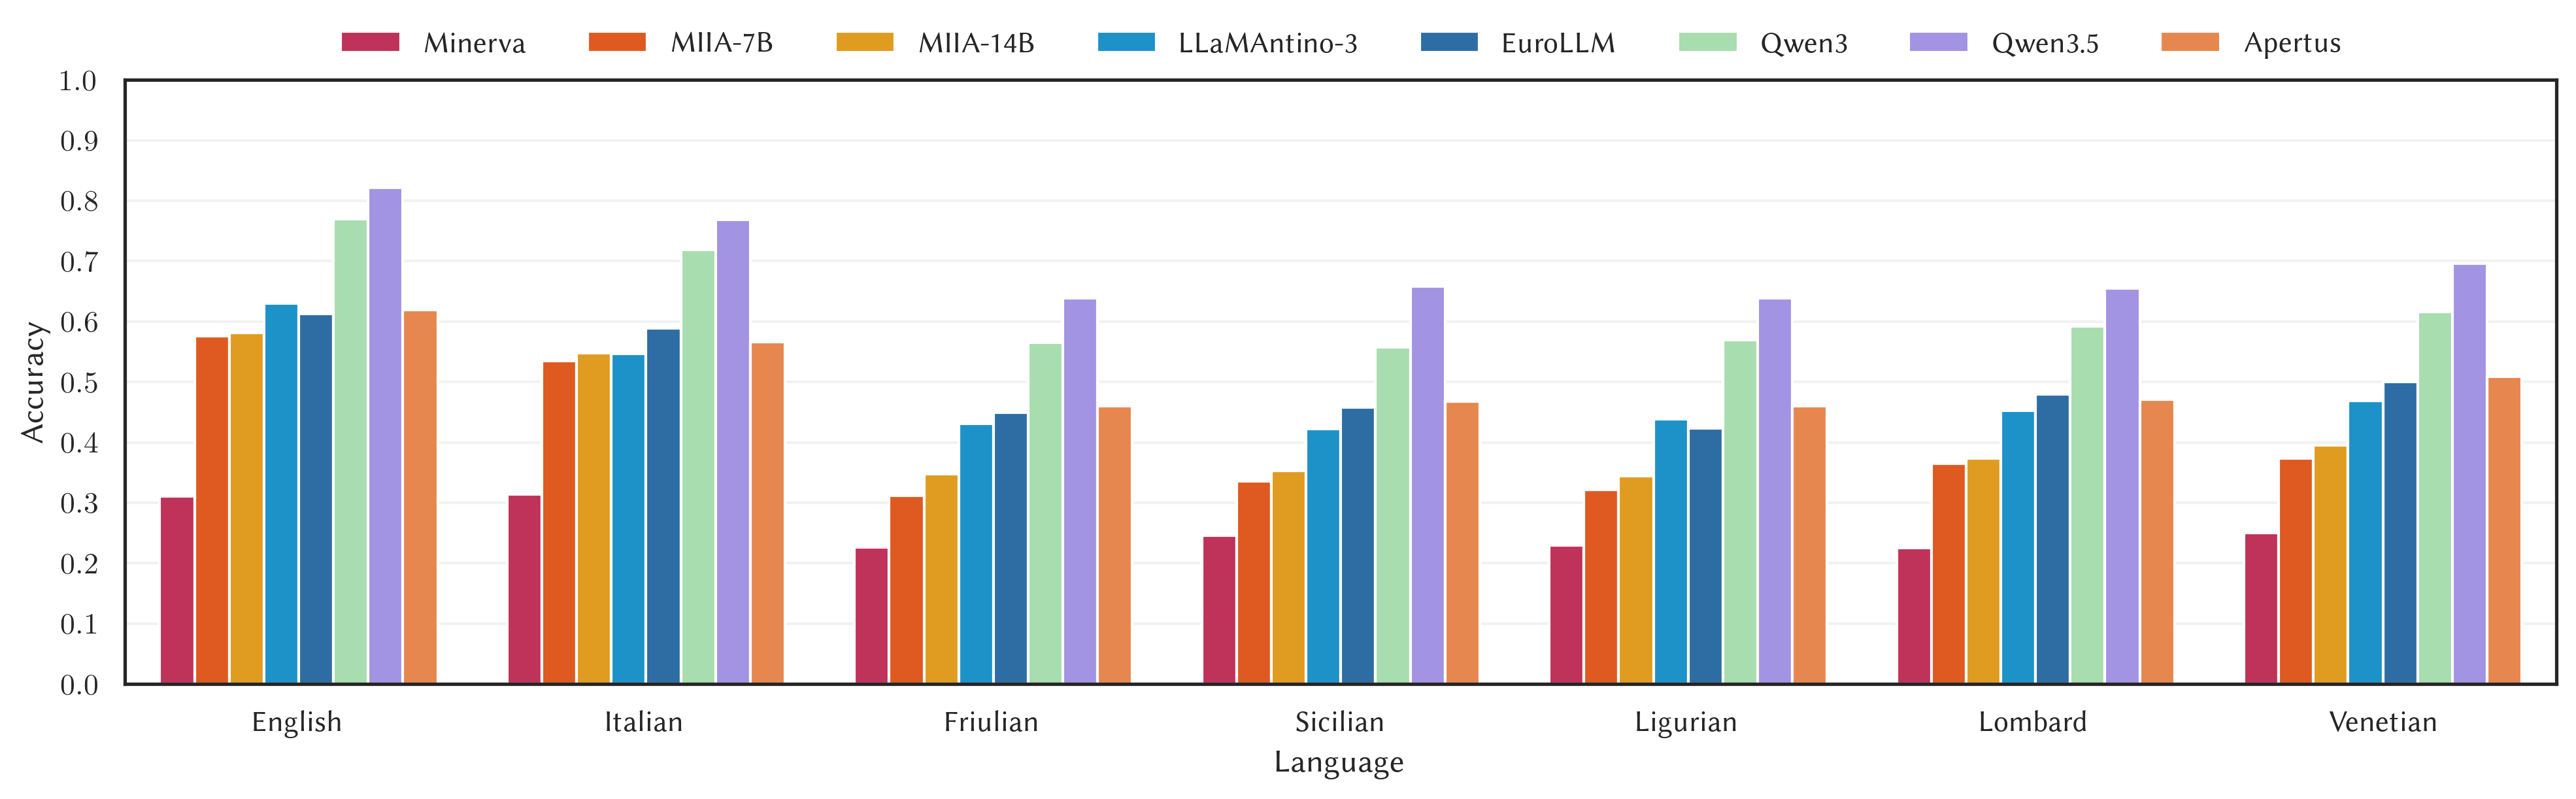

In [46]:
metrics_df = metrics_df.sort_values(["model"])
# weighted F1 by language and model

sns.set_style("white")

plt.figure(figsize=(16, 4), dpi=300)
ax = sns.barplot(data=metrics_df, x="lang", y="accuracy", hue="model", palette=MODELS_COLORS)
# ax.set_title("Accuracy by Language and Model")
ax.set_xlabel("Language")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0.0, 1.01, 0.1))
ax.grid(axis="y", alpha=0.25)
# plt.tight_layout()
plt.legend(ncols=len(models), loc="upper center", fancybox=False, frameon=False, bbox_to_anchor=(0.5, 1.125))
# plt.show()
plt.savefig("../outputs/plots/mmlu_accuracy.png", bbox_inches="tight", dpi=300)

In [10]:
avg_metrics = metrics_df.pivot(index="model", columns="lang", values="accuracy")
avg_metrics

lang,English,Italian,Friulian,Sicilian,Ligurian,Lombard,Venetian
model,,,,,,,
Minerva,0.31,0.31,0.23,0.25,0.23,0.23,0.25
MIIA-7B,0.58,0.54,0.31,0.34,0.32,0.36,0.37
MIIA-14B,0.58,0.55,0.35,0.35,0.34,0.37,0.40
LLaMAntino-3,0.63,0.55,0.43,0.42,0.44,0.45,0.47
EuroLLM,0.61,0.59,0.45,0.46,0.42,0.48,0.50
Qwen3,0.77,0.72,0.56,0.56,0.57,0.59,0.62
Qwen3.5,0.82,0.77,0.64,0.66,0.64,0.65,0.70
Apertus,0.62,0.57,0.46,0.47,0.46,0.47,0.51


In [11]:
df["category"] = df["category"].map(lambda x: "other" if x.startswith("other") else x)

metrics_df_grouped = df.groupby(["lang", "model", "category"], as_index=False, observed=True).apply(
    compute_metrics,
    include_groups=False,  # pyright: ignore[reportCallIssue]
)
tab = metrics_df_grouped.pivot_table(index=["category", "model"], columns="lang", values="accuracy", observed=False)

# add average across the categories
metrics_df["category"] = "average"

final_df = pd.concat([metrics_df, metrics_df_grouped])
final_df["category"] = final_df["category"].astype(
    pd.CategoricalDtype(["humanities", "STEM", "social sciences", "other", "average"])
)
final_tab = final_df.pivot_table(index=["category", "model"], columns="lang", values="accuracy", observed=False)
final_tab

lang                          English  Italian  Friulian  Sicilian  Ligurian  \
category        model                                                          
humanities      Minerva          0.36     0.35      0.24      0.26      0.23   
                MIIA-7B          0.63     0.56      0.34      0.36      0.33   
                MIIA-14B         0.63     0.60      0.39      0.38      0.37   
                LLaMAntino-3     0.70     0.64      0.48      0.50      0.51   
                EuroLLM          0.66     0.64      0.50      0.54      0.49   
                Qwen3            0.78     0.73      0.56      0.58      0.59   
                Qwen3.5          0.83     0.78      0.64      0.68      0.65   
                Apertus          0.66     0.62      0.50      0.53      0.51   
STEM            Minerva          0.27     0.27      0.21      0.23      0.22   
                MIIA-7B          0.48     0.44      0.28      0.31      0.30   
                MIIA-14B         0.48     0.45      0.31      0.32      0.32   
                LLaMAntino-3     0.48     0.42      0.36      0.34      0.36   
                EuroLLM          0.49     0.48      0.38      0.37      0.35   
                Qwen3            0.73     0.70      0.57      0.55      0.56   
                Qwen3.5          0.79     0.73      0.62      0.62      0.62   
                Apertus          0.51     0.46      0.38      0.38      0.39   
social sciences Minerva          0.30     0.31      0.21      0.24      0.23   
                MIIA-7B          0.64     0.60      0.31      0.33      0.32   
                MIIA-14B         0.64     0.59      0.34      0.36      0.33   
                LLaMAntino-3     0.72     0.59      0.45      0.44      0.45   
                EuroLLM          0.70     0.67      0.46      0.49      0.43   
                Qwen3            0.80     0.74      0.56      0.57      0.58   
                Qwen3.5          0.86     0.81      0.65      0.67      0.65   
                Apertus          0.67     0.61      0.49      0.50      0.48   
other           Minerva          0.33     0.34      0.24      0.26      0.24   
                MIIA-7B          0.60     0.58      0.33      0.35      0.34   
                MIIA-14B         0.63     0.59      0.37      0.37      0.37   
                LLaMAntino-3     0.69     0.58      0.45      0.45      0.46   
                EuroLLM          0.66     0.62      0.48      0.47      0.45   
                Qwen3            0.77     0.71      0.56      0.54      0.56   
                Qwen3.5          0.83     0.78      0.65      0.67      0.65   
                Apertus          0.68     0.61      0.50      0.50      0.49   
average         Minerva          0.31     0.31      0.23      0.25      0.23   
                MIIA-7B          0.58     0.54      0.31      0.34      0.32   
                MIIA-14B         0.58     0.55      0.35      0.35      0.34   
                LLaMAntino-3     0.63     0.55      0.43      0.42      0.44   
                EuroLLM          0.61     0.59      0.45      0.46      0.42   
                Qwen3            0.77     0.72      0.56      0.56      0.57   
                Qwen3.5          0.82     0.77      0.64      0.66      0.64   
                Apertus          0.62     0.57      0.46      0.47      0.46   

lang                          Lombard  Venetian  
category        model                            
humanities      Minerva          0.24      0.28  
                MIIA-7B          0.38      0.42  
                MIIA-14B         0.42      0.46  
                LLaMAntino-3     0.51      0.53  
                EuroLLM          0.55      0.55  
                Qwen3            0.60      0.64  
                Qwen3.5          0.67      0.70  
                Apertus          0.53      0.56  
STEM            Minerva          0.22      0.23  
                MIIA-7B          0.34      0.32  
                MIIA-14B         0.33  

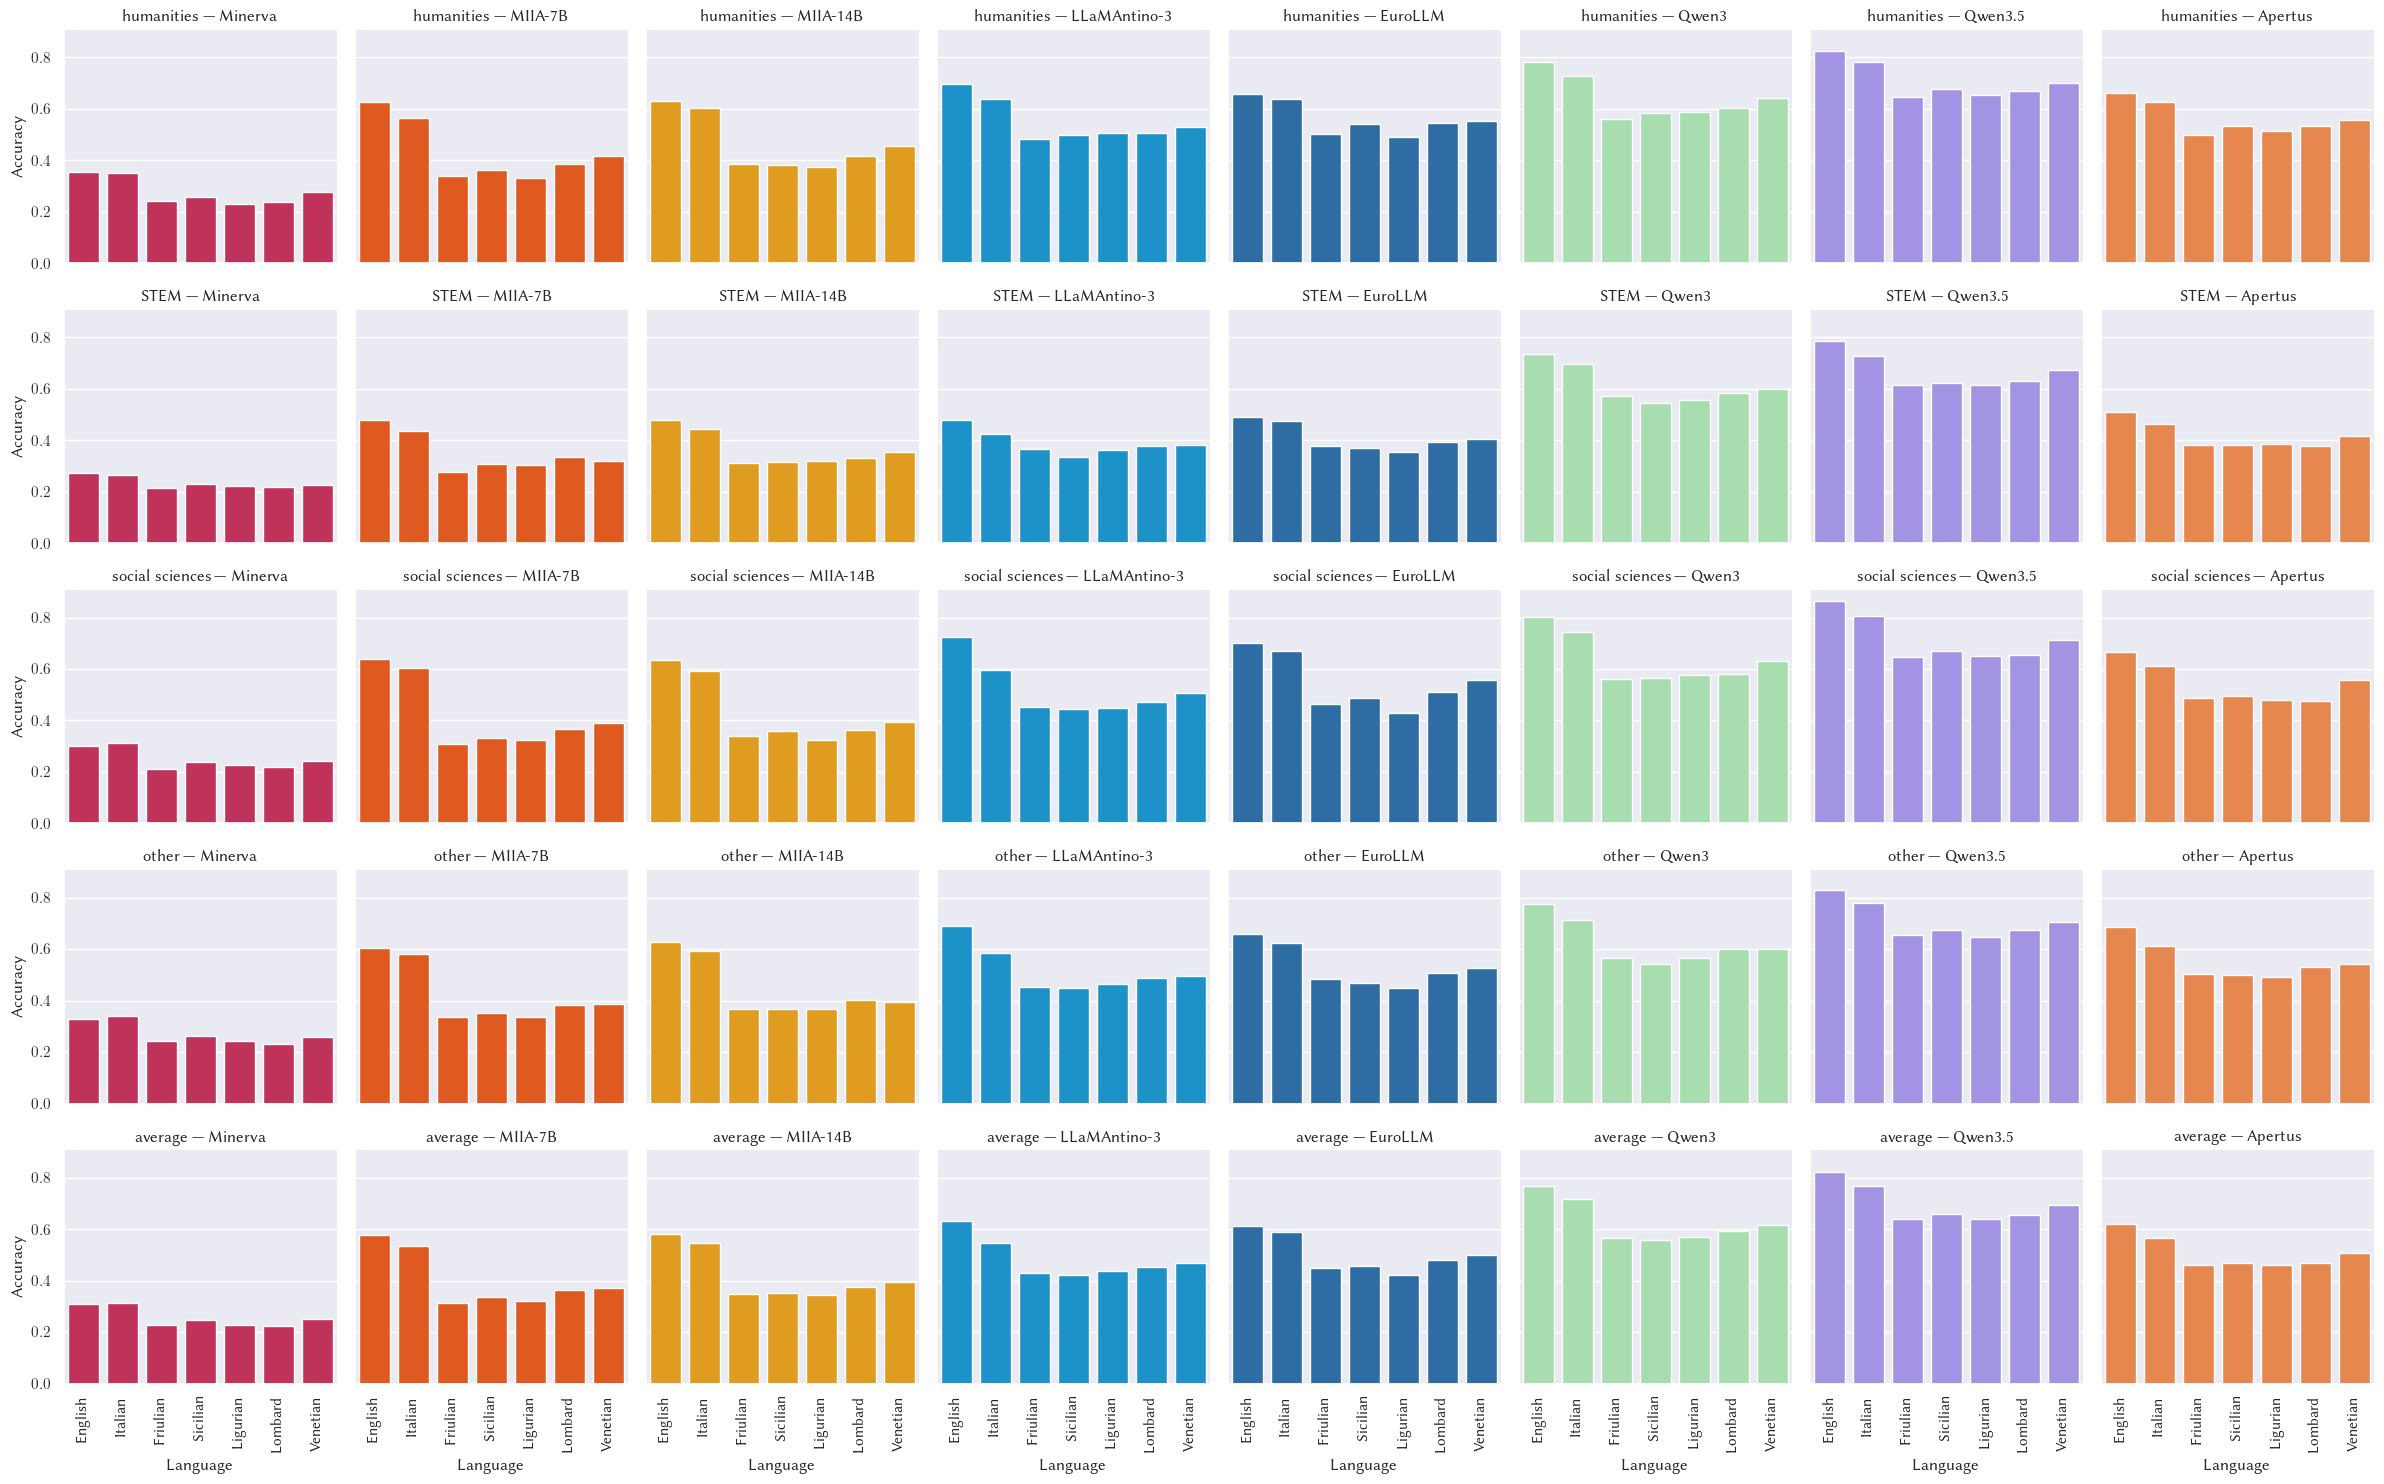

In [18]:
# per category plot
final_df = final_df.sort_values(["model", "category"])
sns.set_style("darkgrid")

g = sns.FacetGrid(final_df, row="category", col="model")
g.map_dataframe(sns.barplot, x="lang", y="accuracy", hue="model", palette=MODELS_COLORS)
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_xticklabels(labels=final_df["lang"].unique(), rotation=90)
g.set_axis_labels("Language", "Accuracy")
plt.tight_layout()
plt.show()

## Confidence Calibration Analysis

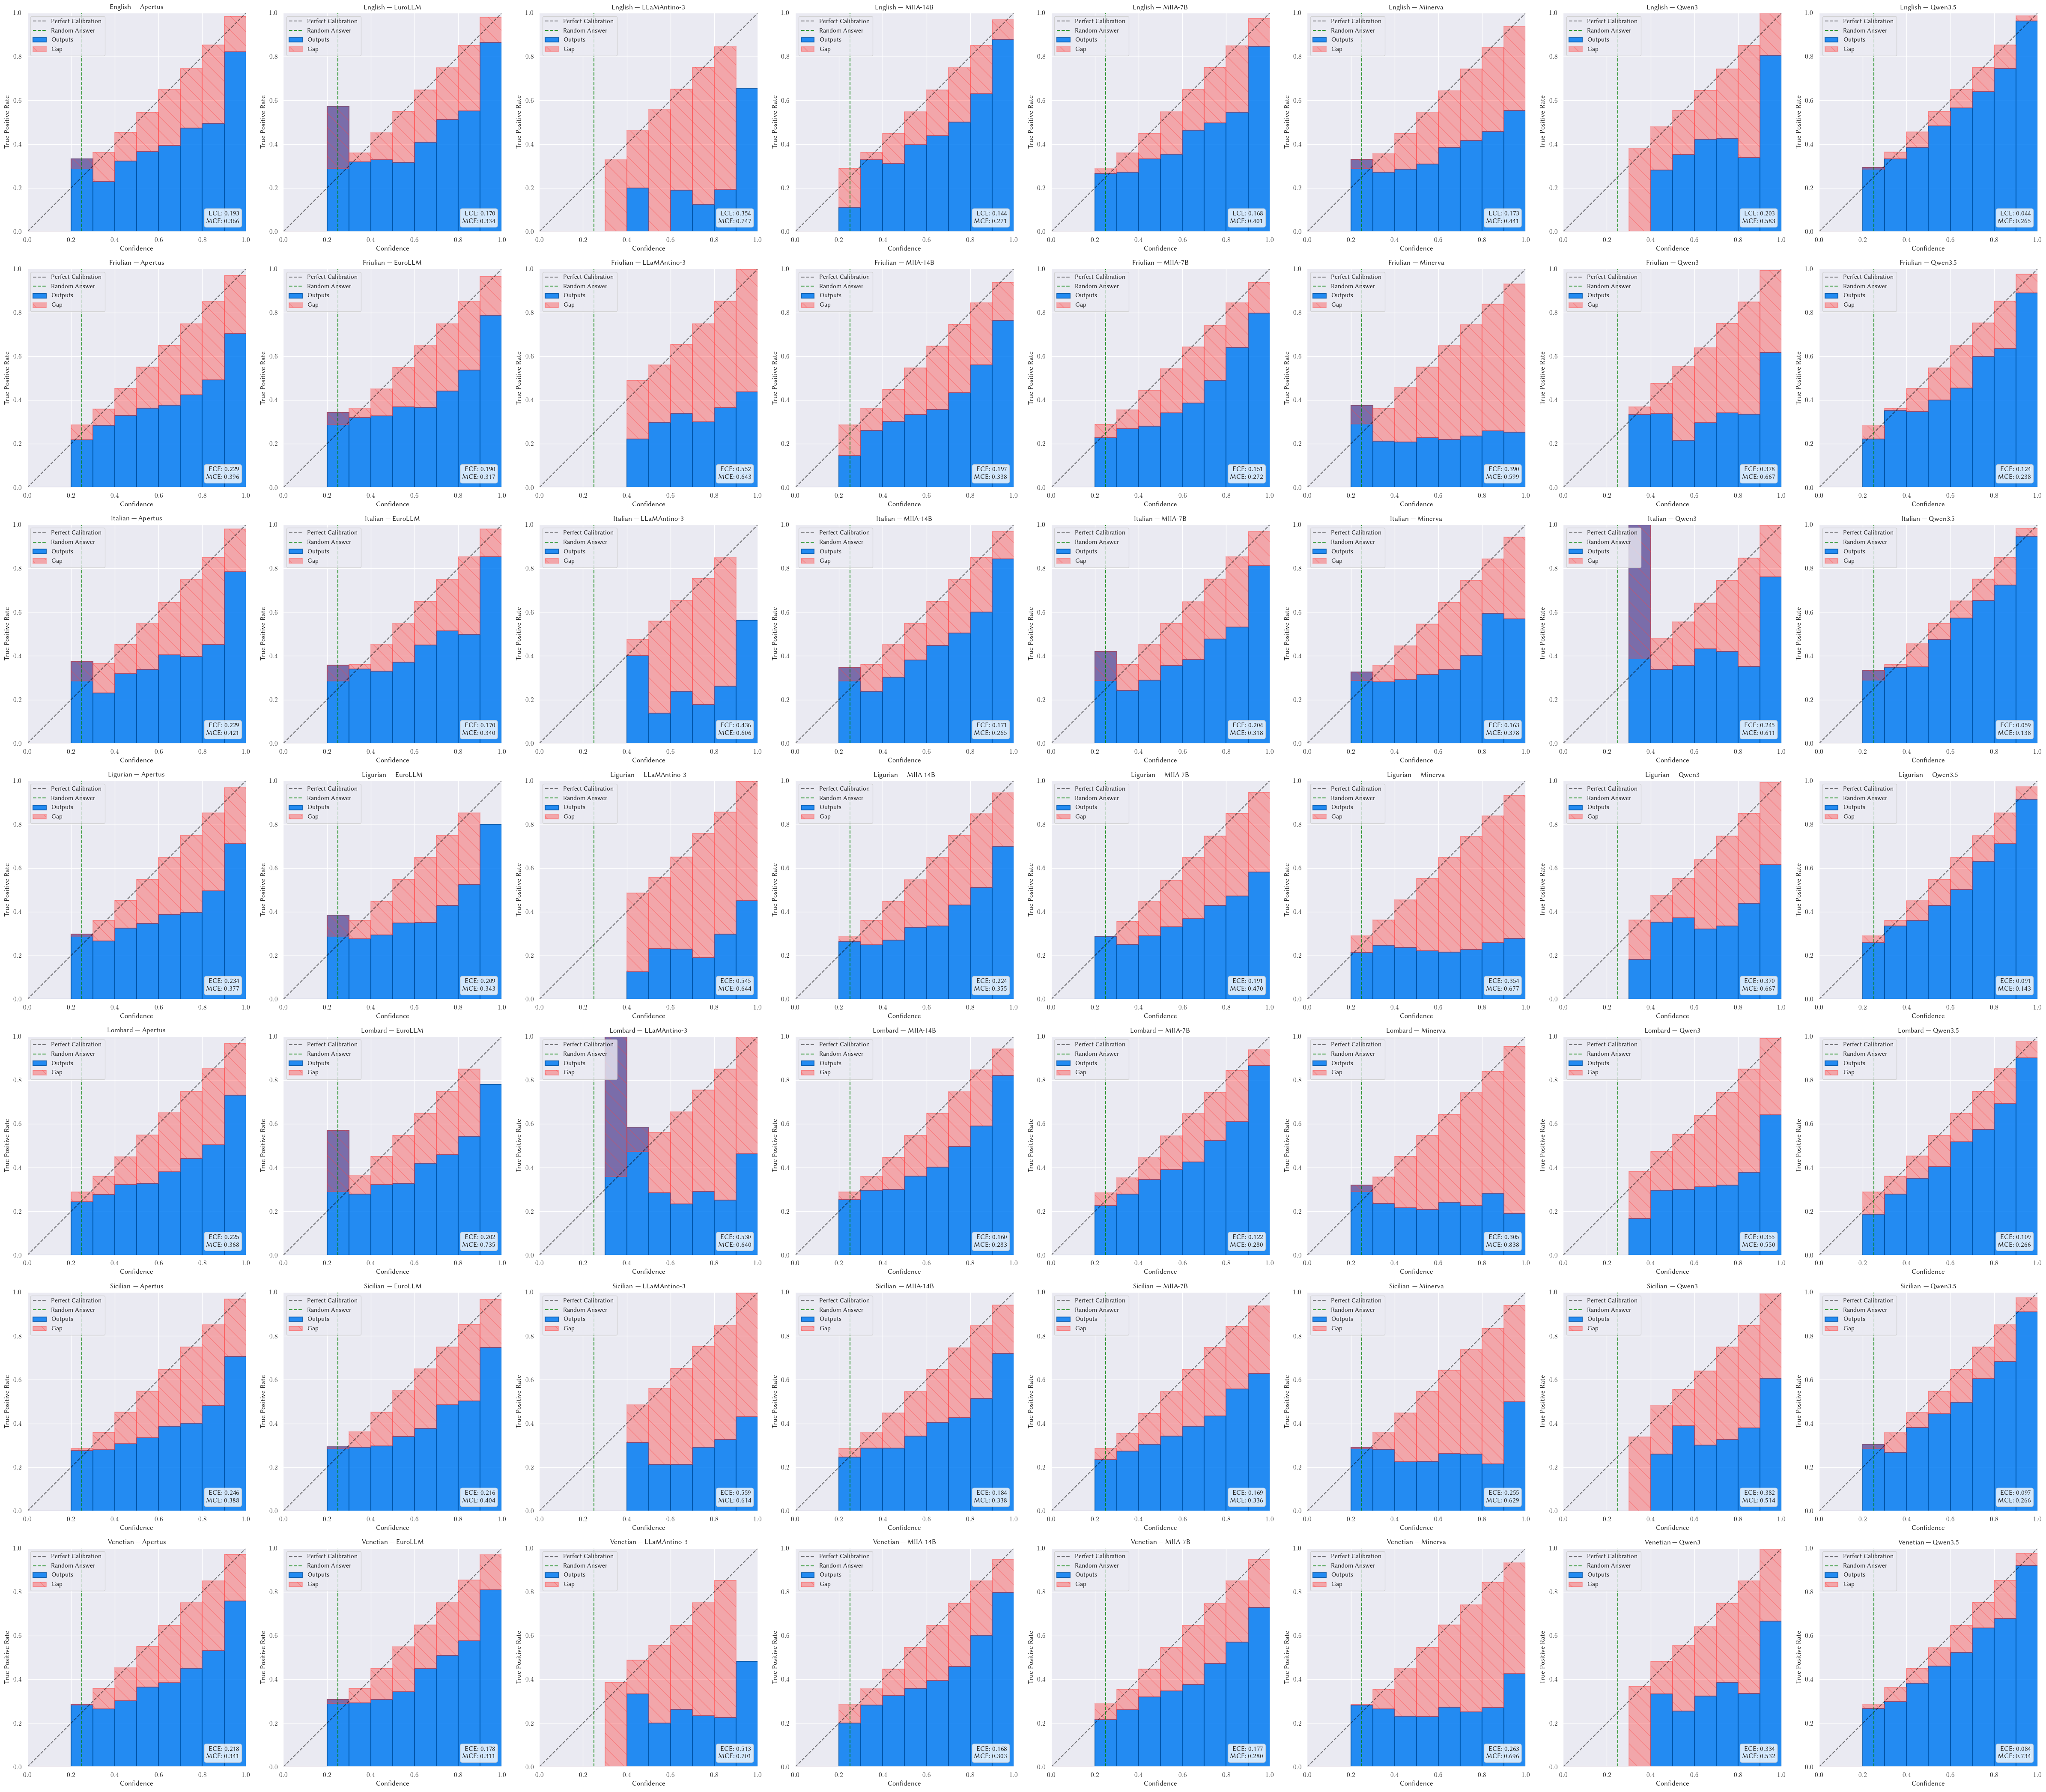

In [13]:
# reliability diagrams using saiteki-kai/calibration
repo_dir = Path("/tmp/calibration")  # noqa: S108
if not repo_dir.exists():
    subprocess.run(["git", "clone", "https://github.com/saiteki-kai/calibration", str(repo_dir)], check=True)  # noqa: S603, S607
if str(repo_dir) not in sys.path:
    sys.path.insert(0, str(repo_dir))
reliability_diagram = importlib.import_module("src.evaluation.visualization").reliability_diagram

n_bins = 10
ece_bins = 15
langs = sorted(df["lang"].unique())
models = sorted(df["model"].unique())

fig, axes = plt.subplots(len(langs), len(models), figsize=(6 * len(models), 6 * len(langs)))
axes = np.atleast_2d(axes)

for i, lang in enumerate(langs):
    for j, model in enumerate(models):
        ax = axes[i, j]
        sub = df[(df["lang"] == lang) & (df["model"] == model)]
        if sub.empty:
            ax.set_visible(False)
            continue

        reliability_diagram(
            ax=ax,
            true_labels=sub["correct"].to_numpy(),
            pred_probs=sub["confidence"].to_numpy(),
            n_bins=n_bins,
            ece_bins=ece_bins,
            title=f"{lang} — {model}",
        )

        ax.axvline(0.25, color="green", linestyle="--", linewidth=1.5, alpha=0.8, label="Random Answer")

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles, strict=True))
        ax.legend(unique.values(), unique.keys(), loc="upper left")

plt.tight_layout()
plt.show()

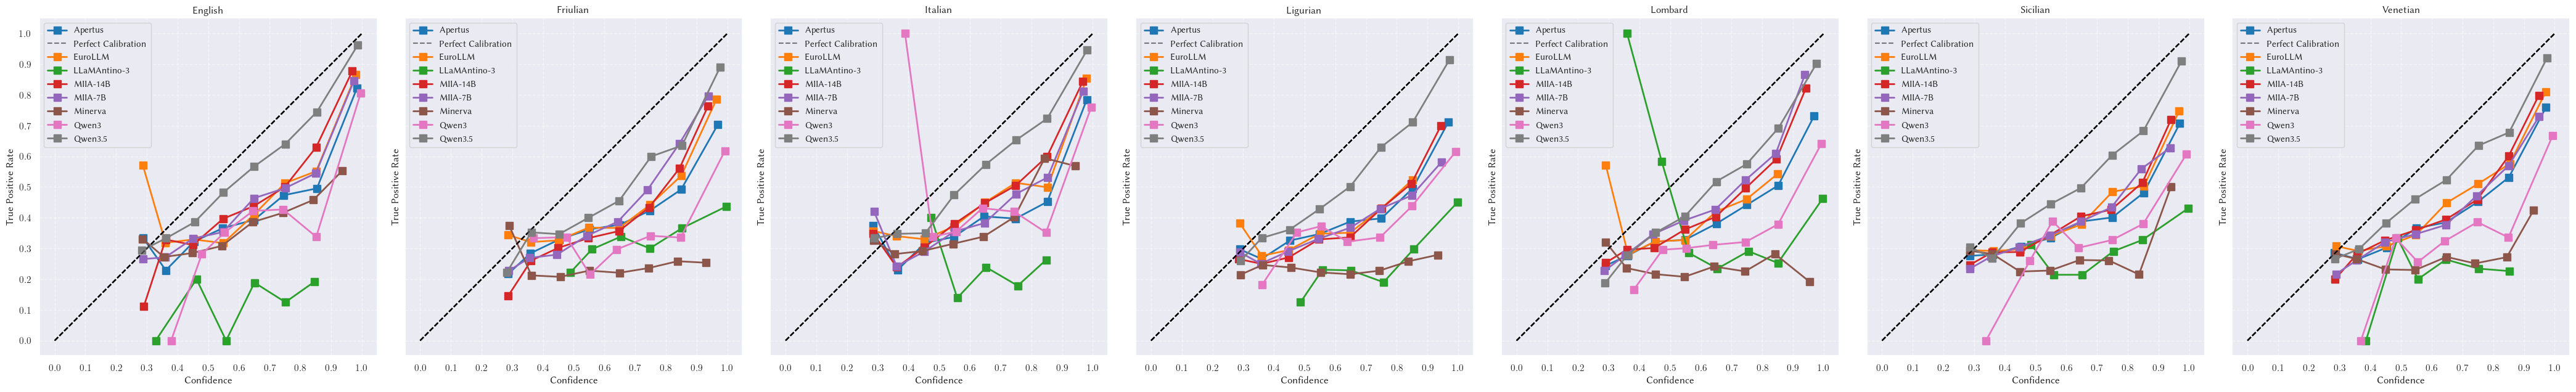

In [14]:
# calibration curves using saiteki-kai/calibration
calibration_curve = importlib.import_module("src.evaluation.visualization").calibration_curve

langs = sorted(df["lang"].unique())
models = sorted(df["model"].unique())
fig, axes = plt.subplots(1, len(langs), figsize=(6 * len(langs), 6), sharey=True)
axes = np.atleast_1d(axes)

for ax, lang in zip(axes, langs, strict=True):
    lang_df = df[df["lang"] == lang]

    for model in models:
        sub = lang_df[lang_df["model"] == model]
        if sub.empty:
            continue

        calibration_curve(
            ax=ax,
            true_labels=sub["correct"].to_numpy(),
            pred_probs=sub["confidence"].to_numpy(),
            n_bins=10,
            title=lang,
            label=model,
        )

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles, strict=True))
    ax.legend(unique.values(), unique.keys(), loc="upper left")

plt.tight_layout()
plt.show()